In [21]:
import matplotlib.pyplot as plt

In [80]:
import torch
import h5py
import numpy as np

path = "/Users/emilfahretdinov/msc_hse/data/datasets/turbulent_radiative_layer_2D/data/test/turbulent_radiative_layer_tcool_0.03.hdf5"

with h5py.File(path, "r") as f:
    density = f["t0_fields"]["density"][:]     # (N, T, H, W)
    pressure = f["t0_fields"]["pressure"][:]   # (N, T, H, W)
    velocity = f["t1_fields"]["velocity"][:]   # (N, T, H, W, 2)

In [81]:
density.shape

(1, 101, 128, 384)

In [62]:
import imageio
import matplotlib.pyplot as plt
import numpy as np

vmin = np.nanmin(density[0])
vmax = np.nanmax(density[0])

fig, ax = plt.subplots()
frames = []

for t in range(100):
    ax.clear()
    ax.imshow(density[0][t], cmap="RdBu_r", interpolation="none", vmin=vmin, vmax=vmax)
    ax.set_title(f"t = {t}")
    ax.axis("off")

    fig.canvas.draw()

    image = np.asarray(fig.canvas.buffer_rgba()).copy()
    frames.append(image)

plt.close(fig)

imageio.mimsave("density.gif", frames, fps=10, loop=0)

In [ ]:
import imageio
import matplotlib.pyplot as plt
import numpy as np

vmin = velocity[...,0][0]
vmax = velocity[...,0][0].max()

fig, ax = plt.subplots()
frames = []

for t in range(100):
    ax.clear()
    ax.imshow(velocity[...,0][0][t], cmap="turbo", vmin=vmin, vmax=vmax)
    ax.set_title(f"t = {t}")
    ax.axis("off")

    fig.canvas.draw()

    image = np.asarray(fig.canvas.buffer_rgba()).copy()
    frames.append(image)

plt.close(fig)

imageio.mimsave("velocity_x.gif", frames, fps=10, loop=0)

In [57]:
traj_id = 0

dens = density[traj_id]      # (T, H, W)
pres = pressure[traj_id]     # (T, H, W)
vel = velocity[traj_id]      # (T, H, W, 2)

vx = vel[..., 0]             # (T, H, W)
vy = vel[..., 1]             # (T, H, W)

traj = np.stack([dens, pres, vx, vy], axis=-1)   # (T, H, W, 4)
traj = torch.tensor(traj, dtype=torch.float32)

print(traj.shape)

torch.Size([101, 128, 384, 4])


In [ ]:
import torch
import numpy as np
from einops import rearrange
from the_well.benchmark.models import FNO
from the_well.data import WellDataset
from the_well.data.normalization import ZScoreNormalization
from the_well.benchmark.metrics import VRMSE


base_path = "./data"
device = torch.device("cpu")

model = FNO.from_pretrained(
    "polymathic-ai/FNO-turbulent_radiative_layer_2D"
).to(device).eval()

In [ ]:
# only needed to get normalization stats + metadata
dset = WellDataset(
    well_base_path=f"{base_path}/datasets",
    well_dataset_name="turbulent_radiative_layer_2D",
    well_split_name="test",
    n_steps_input=4,
    n_steps_output=1,
    use_normalization=True,
    normalization_type=ZScoreNormalization,
)

F = dset.metadata.n_fields
norm = dset.norm

mean_full = norm.flattened_means["variable"].to(device)       # (F,)
std_full  = norm.flattened_stds["variable"].to(device)        # (F,)
mean_d    = norm.flattened_means_delta["variable"].to(device) # (F,)
std_d     = norm.flattened_stds_delta["variable"].to(device)  # (F,)


traj = traj.to(device)

print("traj shape:", traj.shape)  # e.g. (101, 128, 384, 4)

# first 4 frames = input
x_raw = traj[:4]      # (4, H, W, F)

# next frame = target
y_raw = traj[4:5]     # (1, H, W, F)


x_norm = (x_raw - mean_full) / std_full     # (4, H, W, F)
y_norm = (y_raw - mean_full) / std_full     # (1, H, W, F)

# model expects shape: (B, Ti*F, H, W)
x_in = rearrange(x_norm, "Ti H W F -> 1 (Ti F) H W")

with torch.no_grad():
    # model predicts normalized DELTA
    pred_delta_norm = model(x_in)

    # reshape to (To=1, H, W, F)
    pred_delta_norm = rearrange(
        pred_delta_norm,
        "1 (To F) H W -> To H W F",
        To=1,
        F=F
    )


last_input_full_norm = x_norm[-1]         # (H, W, F)
pred_delta_norm = pred_delta_norm[0]      # (H, W, F)

# convert both to raw space
last_raw = last_input_full_norm * std_full + mean_full
delta_raw = pred_delta_norm * std_d + mean_d

# predicted next full frame in raw space
pred_full_raw = last_raw + delta_raw      # (H, W, F)

# normalize predicted full frame for metric comparison
pred_full_norm = (pred_full_raw - mean_full) / std_full   # (H, W, F)

# add output-time dimension so shapes match target
pred_full_norm = pred_full_norm.unsqueeze(0)   # (1, H, W, F)


err2 = (pred_full_norm - y_norm) ** 2  # (1, H, W, F)

mse_f = err2.mean(dim=(0, 1, 2))       # (F,)
var_f = y_norm.var(dim=(0, 1, 2), unbiased=False)  # (F,)

vrmse_per_field = torch.sqrt(mse_f / (var_f + 1e-7))
vrmse_mean_fields = vrmse_per_field.mean()

print("per-field VRMSE:", vrmse_per_field.tolist())
print("mean(per-field VRMSE):", vrmse_mean_fields.item())


vrmse_official = VRMSE.eval(
    pred_full_norm,   # predicted FULL normalized next frame
    y_norm,           # true FULL normalized next frame
    meta=dset.metadata
)

print("official VRMSE:", vrmse_official)
print("official mean VRMSE:", vrmse_official.mean().item())

traj shape: torch.Size([101, 128, 384, 4])
per-field VRMSE: [0.18968920409679413, 1.0674383640289307, 0.2347239851951599, 0.7308264374732971]
mean(per-field VRMSE): 0.5556694865226746
official VRMSE: tensor([[0.1897, 1.0674, 0.2347, 0.7308]])
official mean VRMSE: 0.5556638240814209


/Users/emilfahretdinov/msc_hse/.venv/lib/python3.14/site-packages/tltorch/factorized_tensors/factorized_tensors.py:66: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  return self.__class__(self.tensor[indices])
/Users/emilfahretdinov/msc_hse/.venv/lib/python3.14/site-packages/neuralop/layers/spectral_convolution.py:459: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered 

In [ ]:
import torch
import numpy as np
from einops import rearrange
from the_well.benchmark.models import FNO
from the_well.data import WellDataset
from the_well.data.normalization import ZScoreNormalization
from the_well.benchmark.metrics import VRMSE


T_ROLLOUT = 10


F = dset.metadata.n_fields
norm = dset.norm

mean_full = norm.flattened_means["variable"].to(device)       # (F,)
std_full  = norm.flattened_stds["variable"].to(device)        # (F,)
mean_d    = norm.flattened_means_delta["variable"].to(device) # (F,)
std_d     = norm.flattened_stds_delta["variable"].to(device)  # (F,)

traj = traj.to(device)

print("traj shape:", traj.shape)

# first 4 frames = initial context
x_raw = traj[50:54]                  # (4, H, W, F)

# next 10 frames = rollout target
y_raw = traj[54:54 + T_ROLLOUT]     # (10, H, W, F)

# normalize full-state input and target
x_norm = (x_raw - mean_full) / std_full
y_norm = (y_raw - mean_full) / std_full

# current rolling window of normalized FULL states
x_roll = x_norm.clone()           # (4, H, W, F)

preds_norm = []
preds_raw = []

with torch.no_grad():
    for step in range(T_ROLLOUT):
        # model input: (1, Ti*F, H, W)
        x_in = rearrange(x_roll, "Ti H W F -> 1 (Ti F) H W")

        # model predicts normalized DELTA
        pred_delta_norm = model(x_in)
        pred_delta_norm = rearrange(
            pred_delta_norm,
            "1 (To F) H W -> To H W F",
            To=1,
            F=F
        )[0]   # (H, W, F)

        # last frame in current window = normalized FULL state
        last_input_full_norm = x_roll[-1]   # (H, W, F)

        # convert to raw space
        last_raw = last_input_full_norm * std_full + mean_full
        delta_raw = pred_delta_norm * std_d + mean_d

        # reconstruct next predicted full frame in raw space
        pred_full_raw = last_raw + delta_raw          # (H, W, F)

        # normalize back to full-state normalized space
        pred_full_norm = (pred_full_raw - mean_full) / std_full

        # store predictions
        preds_raw.append(pred_full_raw)
        preds_norm.append(pred_full_norm)

        # autoregressive update:
        # remove oldest frame, append predicted frame
        x_roll = torch.cat([x_roll[1:], pred_full_norm.unsqueeze(0)], dim=0)

# stack rollout predictions
pred_seq_norm = torch.stack(preds_norm, dim=0)   # (T_ROLLOUT, H, W, F)
pred_seq_raw = torch.stack(preds_raw, dim=0)     # (T_ROLLOUT, H, W, F)

print("pred_seq_norm shape:", pred_seq_norm.shape)
print("target y_norm shape:", y_norm.shape)


err2 = (pred_seq_norm - y_norm) ** 2   # (T, H, W, F)

mse_f = err2.mean(dim=(0, 1, 2))       # (F,)
var_f = y_norm.var(dim=(0, 1, 2), unbiased=False)  # (F,)

vrmse_per_field = torch.sqrt(mse_f / (var_f + 1e-7))
vrmse_mean_fields = vrmse_per_field.mean()

print("rollout per-field VRMSE:", vrmse_per_field.tolist())
print("rollout mean(per-field VRMSE):", vrmse_mean_fields.item())

vrmse_official = VRMSE.eval(
    pred_seq_norm,  
    y_norm,        
    meta=dset.metadata
)

print("official rollout VRMSE:", vrmse_official)
print("official rollout mean VRMSE:", vrmse_official.mean().item())


print("\nPer-step rollout VRMSE:")
for step in range(T_ROLLOUT):
    err2_step = (pred_seq_norm[step] - y_norm[step]) ** 2    # (H, W, F)
    mse_f_step = err2_step.mean(dim=(0, 1))
    var_f_step = y_norm[step].var(dim=(0, 1), unbiased=False)

    vrmse_f_step = torch.sqrt(mse_f_step / (var_f_step + 1e-7))
    print(f"step {step+1:02d}: mean={vrmse_f_step.mean().item():.6f}, per-field={vrmse_f_step.tolist()}")

traj shape: torch.Size([101, 128, 384, 4])
pred_seq_norm shape: torch.Size([10, 128, 384, 4])
target y_norm shape: torch.Size([10, 128, 384, 4])
rollout per-field VRMSE: [5577.3193359375, 2136.505859375, 1343.2196044921875, 3803.10205078125]
rollout mean(per-field VRMSE): 3215.03662109375
official rollout VRMSE: tensor([[4.5981e-01, 1.5121e+00, 5.8243e-01, 5.8678e-01],
        [8.1430e-01, 1.3799e+00, 1.1542e+00, 9.2045e-01],
        [1.5125e+00, 2.1242e+00, 1.4019e+00, 8.1352e-01],
        [3.3941e+00, 2.3838e+00, 1.8567e+00, 2.2495e+00],
        [9.8009e+00, 4.8292e+00, 3.6484e+00, 1.0952e+01],
        [3.6783e+01, 1.5649e+01, 1.0783e+01, 3.2239e+01],
        [1.5683e+02, 6.4358e+01, 4.2962e+01, 1.1586e+02],
        [7.1071e+02, 2.7653e+02, 1.7592e+02, 5.8074e+02],
        [3.4276e+03, 1.4386e+03, 7.9157e+02, 2.7737e+03],
        [1.6905e+04, 9.1999e+03, 3.8274e+03, 1.1437e+04]])
official rollout mean VRMSE: 1301.8331298828125

Per-step rollout VRMSE:
step 01: mean=0.785281, per-fiel

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

field_idx = 0
field_name = ["density", "pressure", "vx", "vy"][field_idx]

true_np = y_raw.detach().cpu().numpy()
pred_np = pred_seq_raw.detach().cpu().numpy()

true_field = true_np[..., field_idx]   # (T, H, W)
pred_field = pred_np[..., field_idx]   # (T, H, W)
err_field = np.abs(pred_field - true_field)


# assume these already exist
# true_field: (T, H, W)
# pred_field: (T, H, W)

T = true_field.shape[0]

# optional: stable color scales (recommended)
true_vmin, true_vmax = np.nanpercentile(true_field, [1, 99])
pred_vmin, pred_vmax = np.nanpercentile(pred_field, [1, 99])
err_vmax = np.nanpercentile(err_field, 99)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# initial images
im0 = axes[0].imshow(true_field[0], cmap="RdBu_r", vmin=true_vmin, vmax=true_vmax)
axes[0].set_title("True")
axes[0].axis("off")

im1 = axes[1].imshow(pred_field[0], cmap="RdBu_r", vmin=true_vmin, vmax=true_vmax)
axes[1].set_title("Predicted")
axes[1].axis("off")

im2 = axes[2].imshow(err_field[0], cmap="RdBu_r", vmin=0, vmax=err_vmax)
axes[2].set_title("Abs error")
axes[2].axis("off")

fig.suptitle("Rollout comparison | t = 0")

def update(t):
    im0.set_data(true_field[t])
    im1.set_data(pred_field[t])
    im2.set_data(err_field[t])
    fig.suptitle(f"Rollout comparison | t = {t}")
    return [im0, im1, im2]

ani = FuncAnimation(fig, update, frames=T, blit=False)

ani.save("rollout_comparison.gif", writer=PillowWriter(fps=5))
plt.close(fig)

print("Saved rollout_comparison.gif")

Saved rollout_comparison.gif


In [74]:
%matplotlib inline

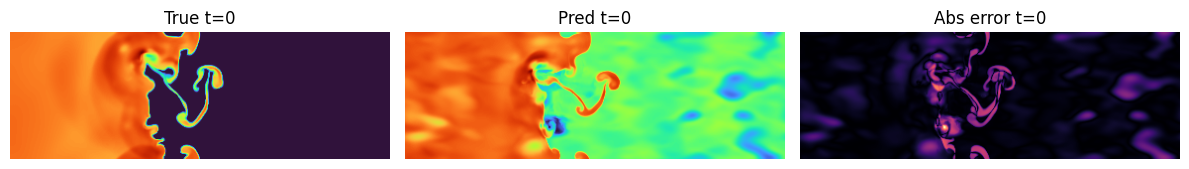

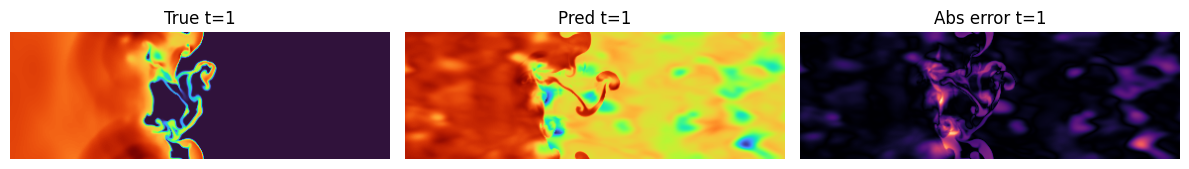

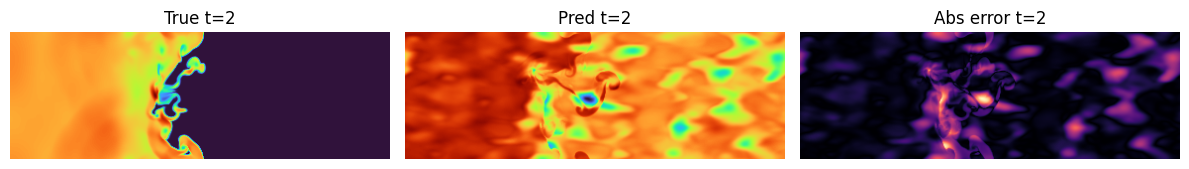

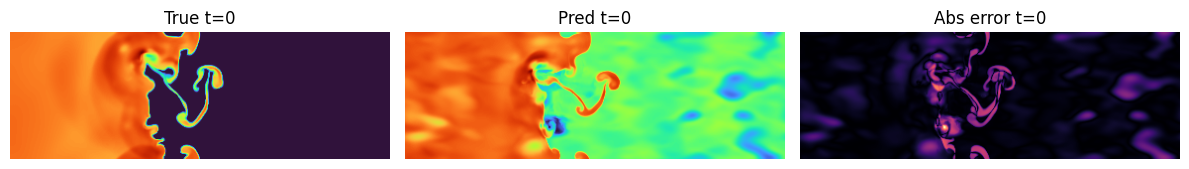

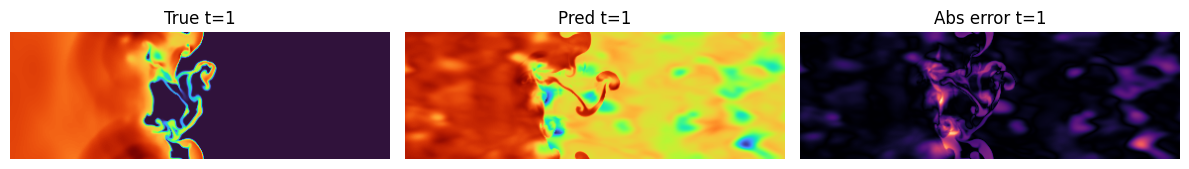

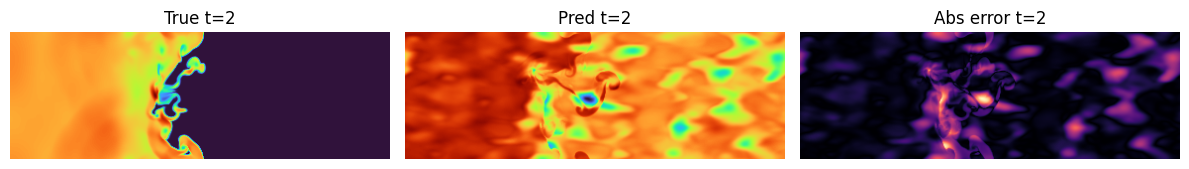

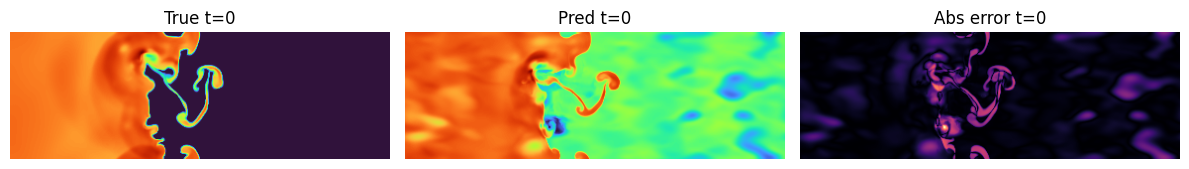

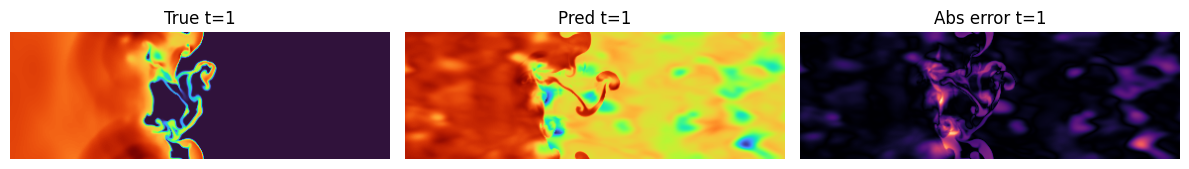

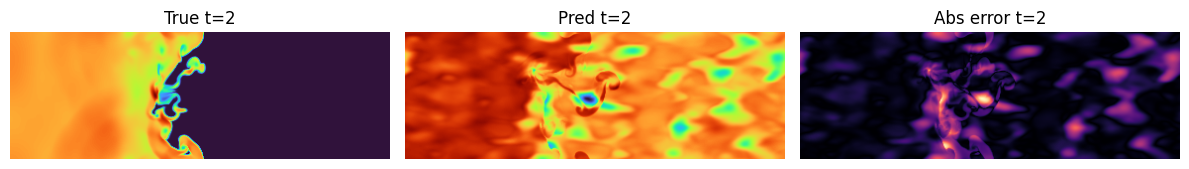

In [ ]:
for t in range(min(3, T)):
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(true_field[t], cmap="Rb")
    plt.title(f"True t={t}")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(pred_field[t], cmap="turbo")
    plt.title(f"Pred t={t}")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(np.abs(pred_field[t] - true_field[t]), cmap="magma")
    plt.title(f"Abs error t={t}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()